In [3]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

num_classes = 10

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# Validation split
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("Train:", x_train.shape)
print("Val:", x_val.shape)
print("Test:", x_test.shape)

Train: (45000, 32, 32, 3)
Val: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [5]:
from tensorflow.keras.applications.resnet50 import preprocess_input

BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (224, 224))
    image = preprocess_input(image)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [6]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.initializers import HeNormal

tf.keras.backend.clear_session()

weight_decay = 1e-4

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # Freeze backbone

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    512,
    kernel_initializer=HeNormal(),
    kernel_regularizer=regularizers.l2(weight_decay)
)(x)

x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    num_classes,
    activation='softmax',
    kernel_regularizer=regularizers.l2(weight_decay)
)(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,643,978 (94.01 MB)

 Trainable params: 1,055,242 (4.03 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [7]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

optimizer = Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_resnet50_model.h5",
    monitor='val_loss',
    save_best_only=True
)

In [8]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8245 - loss: 0.6377

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 164s 106ms/step - accuracy: 0.8245 - loss: 0.6376 - val_accuracy: 0.9068 - val_loss: 0.3951 - learning_rate: 0.0010
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 147s 104ms/step - accuracy: 0.8943 - loss: 0.4419 - val_accuracy: 0.9082 - val_loss: 0.4080 - learning_rate: 0.0010
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 105ms/step - accuracy: 0.8995 - loss: 0.4274 - val_accuracy: 0.9068 - val_loss: 0.4277 - learning_rate: 0.0010
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 147s 104ms/step - accuracy: 0.9022 - loss: 0.4295 - val_accuracy: 0.9096 - val_loss: 0.4246 - learning_rate: 0.0010
Epoch 5/20
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9186 - loss: 0.3897

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 153s 109ms/step - accuracy: 0.9186 - loss: 0.3896 - val_accuracy: 0.9208 - val_loss: 0.3618 - learning_rate: 2.0000e-04
Epoch 6/20
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9363 - loss: 0.3217

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 154s 109ms/step - accuracy: 0.9363 - loss: 0.3217 - val_accuracy: 0.9272 - val_loss: 0.3440 - learning_rate: 2.0000e-04
Epoch 7/20
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9414 - loss: 0.2869

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 109ms/step - accuracy: 0.9414 - loss: 0.2869 - val_accuracy: 0.9270 - val_loss: 0.3274 - learning_rate: 2.0000e-04
Epoch 8/20
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9440 - loss: 0.2656

...

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 148s 105ms/step - accuracy: 0.9562 - loss: 0.2261 - val_accuracy: 0.9286 - val_loss: 0.3142 - learning_rate: 2.0000e-04
Epoch 11/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 147s 104ms/step - accuracy: 0.9579 - loss: 0.2172 - val_accuracy: 0.9262 - val_loss: 0.3143 - learning_rate: 2.0000e-04
Epoch 12/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 147s 104ms/step - accuracy: 0.9629 - loss: 0.1983 - val_accuracy: 0.9250 - val_loss: 0.3169 - learning_rate: 2.0000e-04
Epoch 13/20
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9628 - loss: 0.1971

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 153s 109ms/step - accuracy: 0.9628 - loss: 0.1971 - val_accuracy: 0.9276 - val_loss: 0.3113 - learning_rate: 2.0000e-04
Epoch 14/20
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9663 - loss: 0.1832

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 148s 105ms/step - accuracy: 0.9663 - loss: 0.1832 - val_accuracy: 0.9296 - val_loss: 0.3102 - learning_rate: 2.0000e-04
Epoch 15/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 147s 104ms/step - accuracy: 0.9693 - loss: 0.1764 - val_accuracy: 0.9280 - val_loss: 0.3165 - learning_rate: 2.0000e-04
Epoch 16/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 147s 104ms/step - accuracy: 0.9689 - loss: 0.1740 - val_accuracy: 0.9268 - val_loss: 0.3158 - learning_rate: 2.0000e-04
Epoch 17/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 146s 104ms/step - accuracy: 0.9706 - loss: 0.1699 - val_accuracy: 0.9242 - val_loss: 0.3200 - learning_rate: 2.0000e-04
Epoch 18/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 153s 109ms/step - accuracy: 0.9747 - loss: 0.1571 - val_accuracy: 0.9276 - val_loss: 0.3121 - learning_rate: 4.0000e-05
Epoch 19/20
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9800 - loss: 0.1431

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 148s 105ms/step - accuracy: 0.9800 - loss: 0.1431 - val_accuracy: 0.9284 - val_loss: 0.3084 - learning_rate: 4.0000e-05
Epoch 20/20
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9826 - loss: 0.1377

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 147s 105ms/step - accuracy: 0.9826 - loss: 0.1377 - val_accuracy: 0.9302 - val_loss: 0.3069 - learning_rate: 4.0000e-05


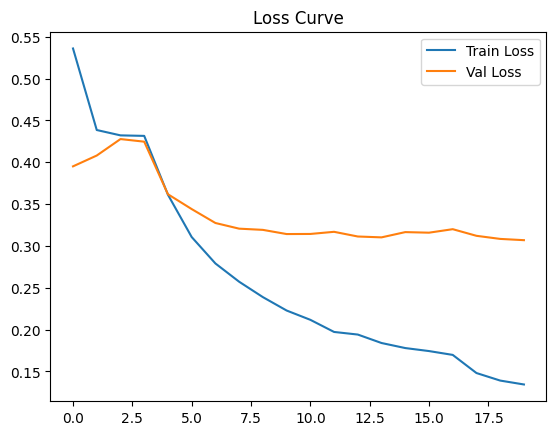

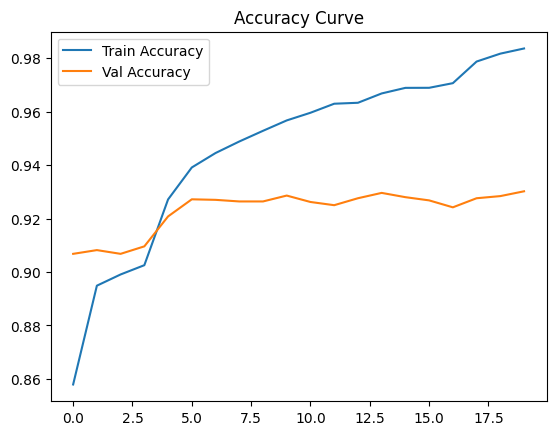

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [10]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 236s 153ms/step - accuracy: 0.9467 - loss: 0.2346 - val_accuracy: 0.9348 - val_loss: 0.3076 - learning_rate: 1.0000e-05
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 203s 144ms/step - accuracy: 0.9785 - loss: 0.1428 - val_accuracy: 0.9392 - val_loss: 0.2989 - learning_rate: 1.0000e-05
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.9857 - loss: 0.1253 - val_accuracy: 0.9424 - val_loss: 0.2969 - learning_rate: 1.0000e-05
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 143ms/step - accuracy: 0.9901 - loss: 0.1129 - val_accuracy: 0.9414 - val_loss: 0.2936 - learning_rate: 1.0000e-05
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 144ms/step - accuracy: 0.9935 - loss: 0.1017 - val_accuracy: 0.9426 - val_loss: 0.2917 - learning_rate: 1.0000e-05
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 202s 143ms/step - accuracy: 0.9951 - loss: 0.0974 - val_accuracy: 0.9418 - val_loss: 0.2950 - learning_rate: 1.0000e-05
Epoch 7/10
1407/1407 ━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 114ms/step


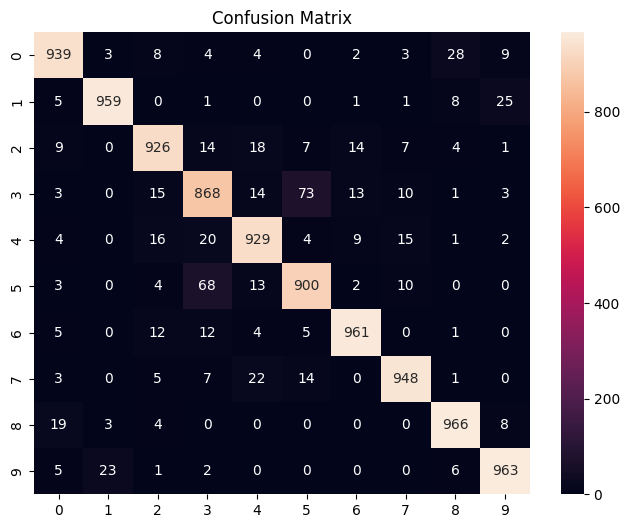

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1000
           1       0.97      0.96      0.96      1000
           2       0.93      0.93      0.93      1000
           3       0.87      0.87      0.87      1000
           4       0.93      0.93      0.93      1000
           5       0.90      0.90      0.90      1000
           6       0.96      0.96      0.96      1000
           7       0.95      0.95      0.95      1000
           8       0.95      0.97      0.96      1000
           9       0.95      0.96      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

predictions = model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))